# Fintech Vital — Modelos de clasificación financiera

**Hackathon ONE G9 (Alura + Oracle) · No Country, equipo 65**

Este notebook entrena y evalúa los dos modelos del proyecto:

| | Modelo | Entrada | Salida |
|---|---|---|---|
| **M1** | Clasificador de transacciones | La descripción, en texto libre | 1 de **12 categorías** |
| **M2** | Clasificador de perfil financiero | **8 indicadores** numéricos | 1 de **3 perfiles** |

Los dos se serializan con `joblib` y los carga el servicio de inferencia
(FastAPI), que es quien los expone al backend.

---

## Índice

1. Datos: de dónde salen y por qué
2. Análisis exploratorio (EDA)
3. Procesamiento de texto e ingeniería de atributos
4. **M1** — clasificación de gastos
5. **M2** — análisis del perfil financiero
6. Comparación contra los *baselines*
7. Serialización de los modelos
8. Conclusiones — incluido lo que **no** funcionó


## 1. Datos: de dónde salen y por qué

El enunciado (§10.1) pide que **cada equipo construya su propio conjunto de
datos**, y admite explícitamente generarlos por simulación. Es lo que hacemos, y
no es un atajo: **no existe un dataset público de transacciones bancarias
etiquetadas en los tres idiomas del proyecto**, y usar movimientos bancarios
reales de personas no sería aceptable ni legal sin su consentimiento.

Los datos se generan con `../datos/generar_dataset.py`, **con semilla fija**, así
que este notebook es reproducible: dos ejecuciones dan exactamente los mismos
números.

### Por qué el proyecto es trilingüe

El sistema debe clasificar en **español, portugués e inglés** (ADR-0009). No es
un detalle de la interfaz: es una propiedad del modelo. Buena parte del jurado es
de Brasil, y un clasificador entrenado solo con comercios mexicanos devuelve
`otros` ante `IFOOD *PEDIDO` o `PIX RECEBIDO`.

Por eso el catálogo de comercios (`../datos/comercios.py`) cubre los tres
mercados de forma **equilibrada**: si hubiera 80 comercios en español y 5 en
portugués, el modelo aprendería español y fingiría saber portugués.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from pathlib import Path

SEMILLA = 42
np.random.seed(SEMILLA)

DATOS = Path("../datos")
ARTEFACTOS = Path("../artefactos")
ARTEFACTOS.mkdir(exist_ok=True)

transacciones = pd.read_csv(DATOS / "dataset_transacciones.csv")
perfiles = pd.read_csv(DATOS / "dataset_perfiles.csv")

print(f"M1 - transacciones: {transacciones.shape[0]} filas, {transacciones.shape[1]} columnas")
print(f"M2 - perfiles     : {perfiles.shape[0]} filas, {perfiles.shape[1]} columnas")
transacciones.head(10)

M1 - transacciones: 2373 filas, 4 columnas
M2 - perfiles     : 3000 filas, 9 columnas


,descripcion,categoria_slug,idioma,comercio
0,INVERSION GBM FONDOS CDMX,ahorro_inversion,es,Inversion GBM Fondos
1,TARJ Cinepolis,entretenimiento,es,Cinepolis
2,CARTAO Tarifa Bancaria Itau,finanzas,pt,Tarifa Bancaria Itau
3,Bonificacao RECIFE,ingresos,pt,Bonificacao
4,Food NEW YORK,alimentacion,en,Food
5,SITIO TAXI REFORMA,transporte,es,Sitio Taxi Reforma
6,Intereses CDMX,finanzas,es,Intereses
7,PAGO SERVICIO Cafe Punta del Cielo,alimentacion,es,Cafe Punta del Cielo
8,Entretenimento,entretenimiento,pt,Entretenimento
9,BRT RIO #2285,transporte,pt,BRT Rio


## 2. Análisis exploratorio (EDA)

Antes de entrenar nada, hay que mirar los datos. Tres preguntas concretas:

1. ¿Hay valores nulos o duplicados?
2. ¿Están las clases equilibradas? *(un modelo entrenado con una clase que domina
   aprende a responder siempre esa clase)*
3. ¿Están los tres idiomas igual de representados?


In [2]:
print("--- Nulos por columna ---")
print(transacciones.isnull().sum())
print()
print("--- Duplicados exactos ---")
print(f"descripciones duplicadas: {transacciones['descripcion'].duplicated().sum()}")
print(f"descripciones unicas    : {transacciones['descripcion'].nunique()}")
print()
print("--- Longitud de las descripciones ---")
print(transacciones["descripcion"].str.len().describe().round(1))

--- Nulos por columna ---
descripcion       0
categoria_slug    0
idioma            0
comercio          0
dtype: int64

--- Duplicados exactos ---
descripciones duplicadas: 0
descripciones unicas    : 2373

--- Longitud de las descripciones ---
count    2373.0
mean       18.9
std         7.8
min         3.0
25%        13.0
50%        18.0
75%        24.0
max        44.0
Name: descripcion, dtype: float64


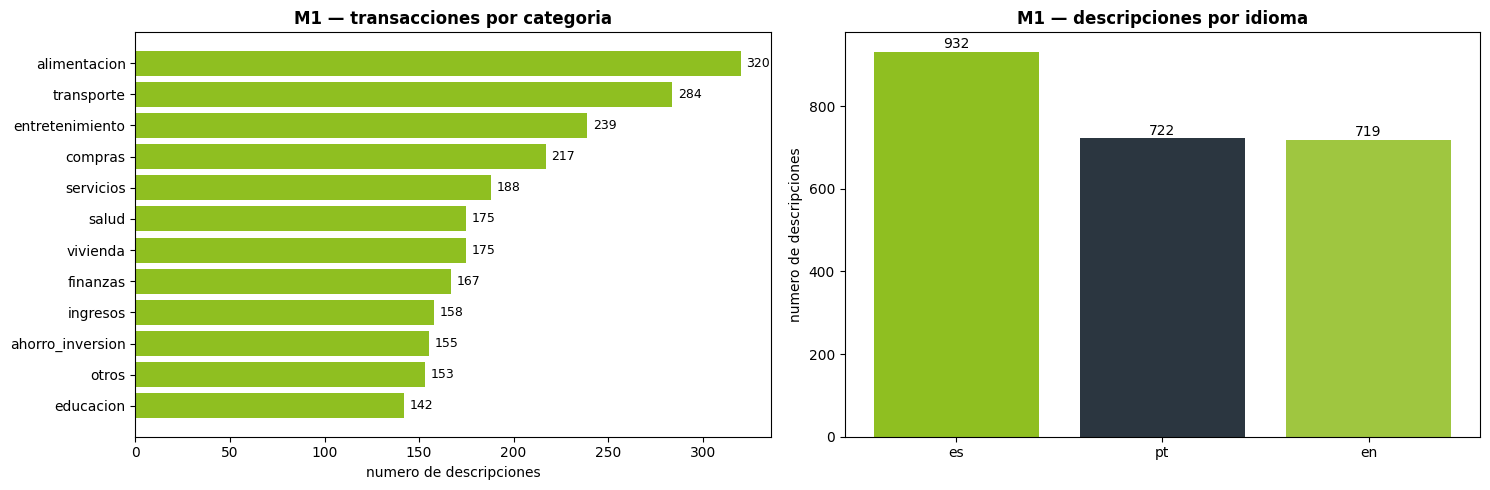

Proporcion de la clase mayoritaria: 0.135


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

conteo = transacciones["categoria_slug"].value_counts().sort_values()
axes[0].barh(conteo.index, conteo.values, color="#8fbf21")
axes[0].set_title("M1 — transacciones por categoria", fontsize=12, weight="bold")
axes[0].set_xlabel("numero de descripciones")
for i, v in enumerate(conteo.values):
    axes[0].text(v + 3, i, str(v), va="center", fontsize=9)

idiomas = transacciones["idioma"].value_counts()
axes[1].bar(idiomas.index, idiomas.values, color=["#8fbf21", "#2b3640", "#9fc640"])
axes[1].set_title("M1 — descripciones por idioma", fontsize=12, weight="bold")
axes[1].set_ylabel("numero de descripciones")
for i, v in enumerate(idiomas.values):
    axes[1].text(i, v + 8, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print("Proporcion de la clase mayoritaria:",
      round(conteo.max() / conteo.sum(), 3))

**Lectura del gráfico.** Las 12 categorías están presentes y ninguna domina: la
más frecuente no llega al 15% del total. Los tres idiomas están razonablemente
equilibrados.

Aun así, hay diferencias (`alimentacion` tiene más ejemplos que `educacion`),
así que al entrenar se usa **`class_weight="balanced"`**: hace que el modelo
pague igual de caro equivocarse en una clase rara que en una frecuente. Sin eso,
la forma más fácil de bajar el error es responder siempre la clase mayoritaria.


In [4]:
print("=== Ejemplos por idioma ===")
for idi in ["es", "pt", "en"]:
    print(f"\n--- {idi} ---")
    muestra = transacciones[transacciones["idioma"] == idi].sample(6, random_state=SEMILLA)
    for _, fila in muestra.iterrows():
        print(f"  {fila['descripcion'][:44]:46s} -> {fila['categoria_slug']}")

=== Ejemplos por idioma ===

--- es ---
  COMPRA TDC COSTCO                              -> alimentacion
  AUTOBUSES ADO *PS5094DF                        -> transporte
  Impuestos GUADALAJARA                          -> finanzas
  COMPRA TDC AGUA Y SANEAMIENTO SACMEX           -> servicios
  Binance Compra                                 -> ahorro_inversion
  SEVEN ELEVEN                                   -> alimentacion

--- pt ---
  IOF OPERACAO                                   -> finanzas
  Anuidade Cartao Bradesco CURITIBA              -> finanzas
  COMPRA CARTAO Habibs                           -> alimentacion
  Sabesp Agua #9380                              -> servicios
  COMPRA Condominio Edificio Aurora              -> vivienda
  PAGAMENTO ALUGUEL APARTAMENTO                  -> vivienda

--- en ---
  MEDICATION                                     -> salud
  Transport CHICAGO                              -> transporte
  DEBIT IKEA                                     -> viviend

Fíjate en el **ruido de extracto bancario**: `*REF`, `#1234`, `COMPRA EN`,
nombres de ciudad, mayúsculas inconsistentes. Es deliberado. Un banco casi nunca
escribe el nombre limpio, y un modelo entrenado solo con nombres limpios se cae
en producción. Que el modelo vea ese ruido **durante el entrenamiento** es lo que
le enseña a ignorarlo.


In [5]:
# EDA de M2: distribucion de los perfiles y de los indicadores.
INDICADORES = ["tasa_ahorro", "ratio_endeudamiento", "ratio_gasto_ingreso",
               "ratio_gasto_esencial", "ratio_gasto_discrecional",
               "concentracion_gasto", "frecuencia_ahorro_num", "ratio_recurrente"]

print("--- Nulos ---")
print(perfiles.isnull().sum().sum(), "nulos en total")
print()
print("--- Estadisticas de los 8 indicadores ---")
display(perfiles[INDICADORES].describe().round(3))
print()
print("--- Perfiles ---")
print(perfiles["perfil_slug"].value_counts())

--- Nulos ---
0 nulos en total

--- Estadisticas de los 8 indicadores ---


,tasa_ahorro,ratio_endeudamiento,ratio_gasto_ingreso,ratio_gasto_esencial,ratio_gasto_discrecional,concentracion_gasto,frecuencia_ahorro_num,ratio_recurrente
count,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000
mean,0.105,0.332,0.895,0.561,0.204,0.423,1.521,0.247
std,0.257,0.214,0.257,0.191,0.100,0.197,1.098,0.143
min,-0.450,0.000,0.450,0.205,0.047,0.009,0.000,0.005
25%,-0.061,0.167,0.706,0.417,0.129,0.273,1.000,0.134
50%,0.124,0.295,0.876,0.534,0.185,0.414,1.500,0.226
75%,0.294,0.464,1.061,0.676,0.259,0.569,2.000,0.336
max,0.550,0.799,1.450,1.147,0.636,0.961,3.000,0.816



--- Perfiles ---
perfil_slug
en_riesgo         1399
saludable         1005
en_observacion     596
Name: count, dtype: int64


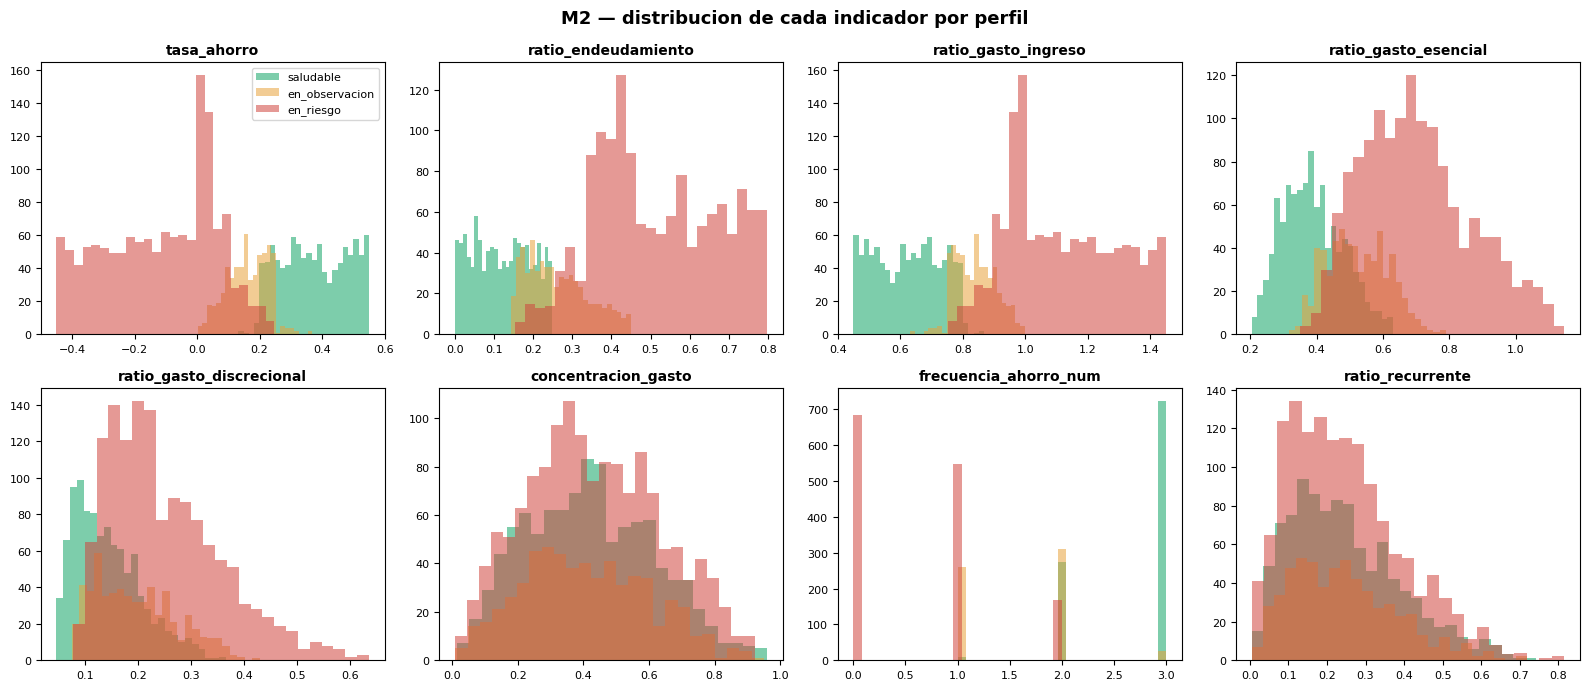

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
colores = {"saludable": "#12a566", "en_observacion": "#e8a33d", "en_riesgo": "#d0453e"}

for ax, indicador in zip(axes.ravel(), INDICADORES):
    for perfil, color in colores.items():
        datos = perfiles.loc[perfiles["perfil_slug"] == perfil, indicador]
        ax.hist(datos, bins=25, alpha=0.55, label=perfil, color=color)
    ax.set_title(indicador, fontsize=10, weight="bold")
    ax.tick_params(labelsize=8)

axes.ravel()[0].legend(fontsize=8)
plt.suptitle("M2 — distribucion de cada indicador por perfil", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

**Lectura.** `tasa_ahorro` y `ratio_endeudamiento` separan visiblemente los tres
perfiles — que es justo lo que dice la taxonomía del proyecto. `ratio_recurrente`
y `concentracion_gasto` se solapan bastante: aportan poco por sí solos, pero
ayudan en los casos de frontera.

Esto **ya nos dice qué esperar**: un modelo que use los ocho debería superar
claramente a una regla que solo mire dos.


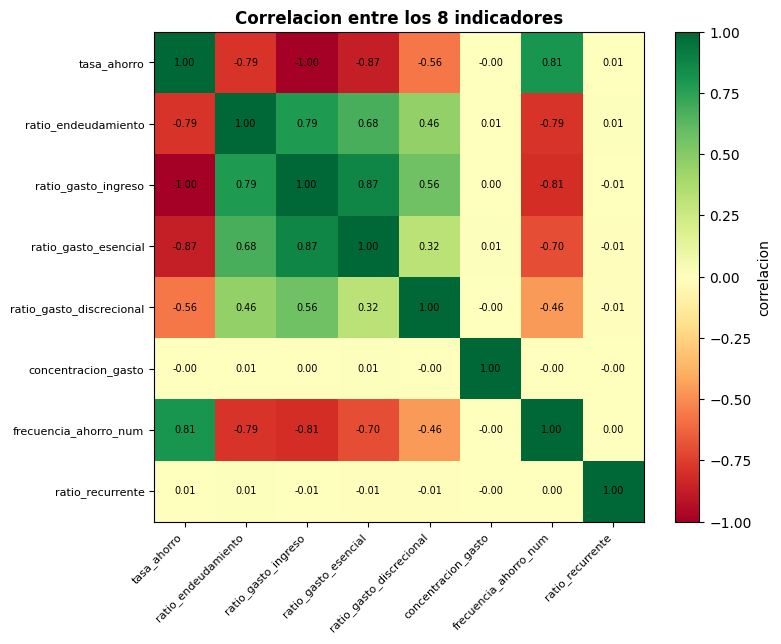

In [7]:
# Correlacion entre indicadores. Si dos midieran lo mismo, uno sobra.
corr = perfiles[INDICADORES].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(INDICADORES)))
ax.set_yticks(range(len(INDICADORES)))
ax.set_xticklabels(INDICADORES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(INDICADORES, fontsize=8)
for i in range(len(INDICADORES)):
    for j in range(len(INDICADORES)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, label="correlacion")
plt.title("Correlacion entre los 8 indicadores", weight="bold")
plt.tight_layout()
plt.show()

`tasa_ahorro` y `ratio_gasto_ingreso` están correlacionados casi a −1, y tiene
sentido: **son la misma información** (lo que ahorras es lo que no gastas). Se
conservan los dos porque el contrato con el backend fija los ocho, y quitar uno
obligaría a cambiar esa interfaz. Un `RandomForest` maneja bien las variables
redundantes, así que no hace daño.


## 3. Procesamiento de texto e ingeniería de atributos

### La decisión importante de M1: cómo convertir texto en números

Un modelo no entiende `"IFOOD *PEDIDO"`. Hay que vectorizarlo, y **cómo se haga
determina si el modelo funciona en tres idiomas o solo en uno.**

Se usa un `FeatureUnion` de **dos** vectorizadores TF-IDF:

| Vectorizador | Qué captura | Por qué hace falta |
|---|---|---|
| `word` (1-2 gramas) | Palabras y pares de palabras | Reconoce marcas: *"Netflix"*, *"Pago de Renta"* |
| `char_wb` (3-5 caracteres) | Trozos de palabra dentro de cada palabra | **Es lo que hace que funcione en 3 idiomas** |

**Por qué `char_wb` es imprescindible.** Los n-gramas de caracteres capturan
raíces compartidas entre lenguas romances:

- `supermerc-` aparece en *supermercado* (es) y *supermercado* (pt)
- `farmac-` en *farmacia* (es/pt) y *pharmacy* (en, parcialmente)
- `combust-` en *combustible* (es) y *combustível* (pt)

Además da robustez ante lo que nunca vio: `DROGASIL` comparte `drog-` con
*drogaria*, así que el modelo lo acerca a `salud` aunque esa marca exacta no
estuviera en el entrenamiento.

Sin `char_wb`, el modelo solo reconoce las palabras exactas que memorizó.


In [8]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

def construir_pipeline_m1():
    """Pipeline completo: recibe texto crudo, devuelve la categoria.

    Va todo dentro de un Pipeline a proposito. Si el vectorizador se guardara
    aparte, quien cargue el modelo tendria que acordarse de aplicarlo antes y
    con los mismos parametros -- y el dia que no coincidan, no falla: predice mal
    en silencio.
    """
    return Pipeline([
        ("features", FeatureUnion([
            ("word_tfidf", TfidfVectorizer(
                analyzer="word", ngram_range=(1, 2),
                sublinear_tf=True, min_df=1)),
            ("char_tfidf", TfidfVectorizer(
                analyzer="char_wb", ngram_range=(3, 5),
                sublinear_tf=True, min_df=1)),
        ])),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",   # que las clases raras pesen igual
            C=10,
            random_state=SEMILLA)),
    ])

pipeline_demo = construir_pipeline_m1()
pipeline_demo.fit(transacciones["descripcion"], transacciones["categoria_slug"])
n_word = len(pipeline_demo.named_steps["features"].transformer_list[0][1].vocabulary_)
n_char = len(pipeline_demo.named_steps["features"].transformer_list[1][1].vocabulary_)
print(f"Atributos generados:")
print(f"  palabras y bigramas : {n_word:6d}")
print(f"  n-gramas de caracter: {n_char:6d}")
print(f"  TOTAL               : {n_word + n_char:6d}")

Atributos generados:
  palabras y bigramas :   3412
  n-gramas de caracter:  12100
  TOTAL               :  15512


## 4. M1 — Clasificación de gastos

### La partición: dónde se cuela la fuga de datos

El error más común al evaluar un clasificador de texto es medir sobre datos que
el modelo ya vio, y hay tres formas de caer. Las dos primeras son conocidas:

1. **Predecir sobre el mismo conjunto con el que se entrenó.** El modelo se lo
   sabe de memoria y la exactitud sale ~1.00 aunque el modelo no sirva.
2. **No estratificar.** Una categoría con pocos ejemplos puede quedar entera
   fuera del conjunto de prueba, y su métrica sería inventada.

La tercera es más sutil, y es la que aplica aquí:

3. **Partir por fila cuando varias filas vienen del mismo comercio.** El dataset
   tiene una descripción única por fila, pero `Burger King`, `BURGER KING #482` y
   `COMPRA EN Burger King CDMX` son **el mismo comercio en tres formatos**. Con
   una partición al azar, unas variantes caen en entrenamiento y otras en prueba:
   el modelo ya vio esa marca y acierta, pero eso **no demuestra que sepa
   clasificar un comercio nuevo**.

Se hacen las **dos** particiones, para poder enseñar la diferencia:

| Partición | Qué mide |
|---|---|
| Por fila (`train_test_split`) | Rendimiento con comercios ya conocidos |
| **Por grupo (`GroupShuffleSplit`)** | **Rendimiento con comercios que nunca vio** |

La segunda es la exigente y es la que se reporta: en producción van a llegar
comercios que no estaban en el entrenamiento.


In [9]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

X = transacciones["descripcion"]
y = transacciones["categoria_slug"]
grupos = transacciones["comercio"]

print(f"descripciones                : {len(X)}")
print(f"comercios/conceptos distintos: {grupos.nunique()}")
print()

# Particion POR GRUPO: ningun comercio puede aparecer en los dos lados.
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEMILLA)
idx_train, idx_test = next(gss.split(X, y, groups=grupos))

X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]
idi_test = transacciones["idioma"].iloc[idx_test]

solapan = set(grupos.iloc[idx_train]) & set(grupos.iloc[idx_test])
print(f"entrenamiento: {len(X_train):5d} descripciones de {grupos.iloc[idx_train].nunique():3d} comercios")
print(f"prueba       : {len(X_test):5d} descripciones de {grupos.iloc[idx_test].nunique():3d} comercios")
print(f"comercios en AMBOS lados: {len(solapan)}   <- tiene que ser 0")
print()
print(f"Categorias presentes en prueba: {y_test.nunique()} de {y.nunique()}")

descripciones                : 2373
comercios/conceptos distintos: 642

entrenamiento:  1767 descripciones de 481 comercios
prueba       :   606 descripciones de 161 comercios
comercios en AMBOS lados: 0   <- tiene que ser 0

Categorias presentes en prueba: 12 de 12


In [10]:
modelo_m1 = construir_pipeline_m1()
modelo_m1.fit(X_train, y_train)

pred_test = modelo_m1.predict(X_test)
pred_train = modelo_m1.predict(X_train)

print("=== M1: rendimiento (particion POR COMERCIO, la exigente) ===")
print(f"  accuracy en ENTRENAMIENTO : {accuracy_score(y_train, pred_train):.3f}  <- memorizacion")
print(f"  accuracy en PRUEBA        : {accuracy_score(y_test, pred_test):.3f}  <- el numero que importa")
print(f"  macro-F1 en PRUEBA        : {f1_score(y_test, pred_test, average='macro'):.3f}")
print()

# La misma medida con particion por FILA, para ver cuanto infla la fuga.
Xtr_f, Xte_f, ytr_f, yte_f = train_test_split(
    X, y, test_size=0.25, random_state=SEMILLA, stratify=y)
modelo_con_fuga = construir_pipeline_m1().fit(Xtr_f, ytr_f)
f1_con_fuga = f1_score(yte_f, modelo_con_fuga.predict(Xte_f), average="macro")
f1_honesto = f1_score(y_test, pred_test, average="macro")

print("=== Cuanto infla partir mal ===")
print(f"  por FILA     (el mismo comercio en ambos lados) : {f1_con_fuga:.3f}")
print(f"  por COMERCIO (comercios nuevos en prueba)       : {f1_honesto:.3f}")
print(f"  lo que regalaba la fuga                         : {f1_con_fuga - f1_honesto:+.3f}")
print()
print("Los dos son 'correctos' segun como se miren, pero solo el segundo responde")
print("la pregunta que importa: como se comporta ante un comercio que nunca vio.")
print("Ese es el que se reporta.")

=== M1: rendimiento (particion POR COMERCIO, la exigente) ===
  accuracy en ENTRENAMIENTO : 1.000  <- memorizacion
  accuracy en PRUEBA        : 0.559  <- el numero que importa
  macro-F1 en PRUEBA        : 0.584



=== Cuanto infla partir mal ===
  por FILA     (el mismo comercio en ambos lados) : 1.000
  por COMERCIO (comercios nuevos en prueba)       : 0.584
  lo que regalaba la fuga                         : +0.416

Los dos son 'correctos' segun como se miren, pero solo el segundo responde
la pregunta que importa: como se comporta ante un comercio que nunca vio.
Ese es el que se reporta.


### Métricas por clase

La exactitud global engaña: con una clase que fuera el 90% de los datos, un
modelo que respondiera siempre esa clase sacaría 0.90 y sería inútil.

Lo que hay que mirar es el **macro-F1**, que promedia el F1 de cada clase dando
el mismo peso a todas, y el desglose por clase.


In [11]:
print(classification_report(y_test, pred_test, zero_division=0))

                  precision    recall  f1-score   support

ahorro_inversion       0.65      0.86      0.74        36
    alimentacion       0.32      0.69      0.44        67
         compras       0.30      0.26      0.28        72
       educacion       0.85      0.52      0.65        42
 entretenimiento       0.73      0.34      0.47        64
        finanzas       0.74      0.68      0.71        50
        ingresos       0.90      0.41      0.57        46
           otros       0.41      0.87      0.55        15
           salud       0.70      0.77      0.73        30
       servicios       0.69      0.68      0.69        53
      transporte       0.74      0.59      0.66        86
        vivienda       0.55      0.51      0.53        45

        accuracy                           0.56       606
       macro avg       0.63      0.60      0.58       606
    weighted avg       0.63      0.56      0.56       606



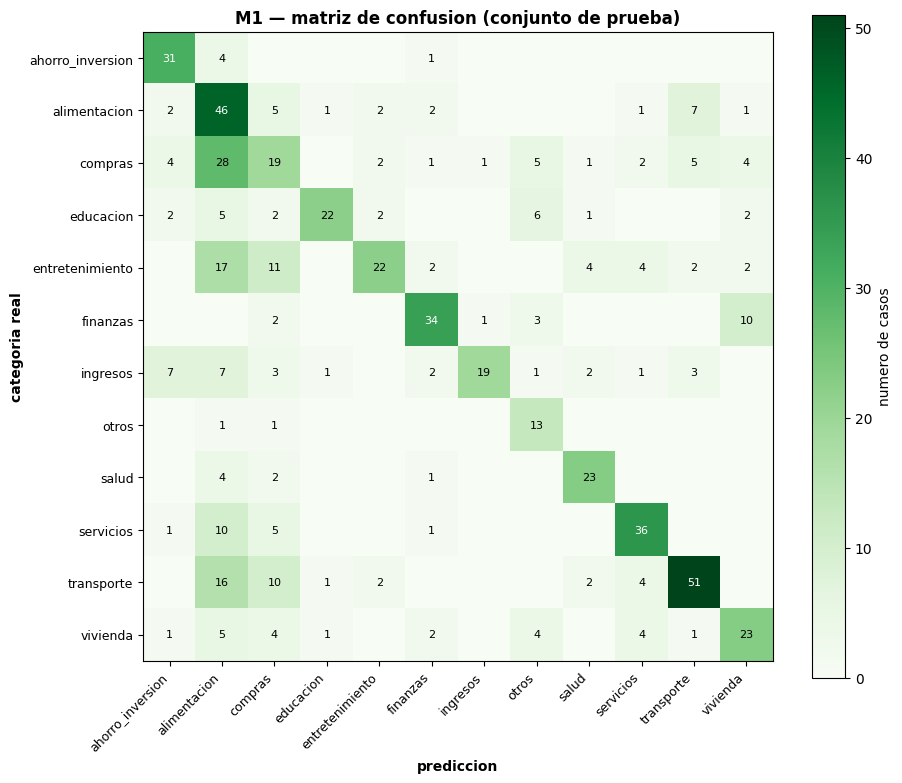

In [12]:
etiquetas = sorted(y.unique())
mc = confusion_matrix(y_test, pred_test, labels=etiquetas)

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(mc, cmap="Greens")
ax.set_xticks(range(len(etiquetas)))
ax.set_yticks(range(len(etiquetas)))
ax.set_xticklabels(etiquetas, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(etiquetas, fontsize=9)
ax.set_xlabel("prediccion", weight="bold")
ax.set_ylabel("categoria real", weight="bold")
ax.set_title("M1 — matriz de confusion (conjunto de prueba)", weight="bold")
for i in range(len(etiquetas)):
    for j in range(len(etiquetas)):
        if mc[i, j]:
            ax.text(j, i, mc[i, j], ha="center", va="center", fontsize=8,
                    color="white" if mc[i, j] > mc.max() * 0.6 else "black")
plt.colorbar(im, label="numero de casos")
plt.tight_layout()
plt.show()

**Cómo se lee.** La diagonal son los aciertos. Cualquier valor fuera de la
diagonal es una confusión entre dos categorías, y ahí es donde se ve qué le
cuesta al modelo.


### 🌎 Métrica por idioma — la que de verdad importa aquí

Un macro-F1 global de 0.95 podría esconder que el modelo saca 0.99 en español y
0.60 en portugués. Como el proyecto es trilingüe y **parte del jurado es de
Brasil**, esa media escondería justo el fallo que no nos podemos permitir.

El contrato del modelo exige **macro-F1 ≥ 0.85 global y ≥ 0.80 en cada idioma**.


In [13]:
print("=== M1: macro-F1 por idioma ===")
filas_idioma = []
for idi in ["es", "pt", "en"]:
    mascara = (idi_test == idi).values
    f1 = f1_score(y_test[mascara], pred_test[mascara], average="macro")
    acc = accuracy_score(y_test[mascara], pred_test[mascara])
    filas_idioma.append({"idioma": idi, "casos": int(mascara.sum()),
                         "accuracy": round(acc, 3), "macro_F1": round(f1, 3),
                         "cumple_>=0.80": "SI" if f1 >= 0.80 else "NO"})
resumen_idioma = pd.DataFrame(filas_idioma)
display(resumen_idioma)

global_f1 = f1_score(y_test, pred_test, average="macro")
print(f"\nmacro-F1 GLOBAL (comercios nuevos): {global_f1:.3f}")
print(f"macro-F1 GLOBAL (comercios conocidos): {f1_con_fuga:.3f}")
print()
print("La meta del contrato es 0.85. Cual de los dos numeros hay que comparar")
print("con ella se discute en la conclusion: NO son la misma pregunta.")

=== M1: macro-F1 por idioma ===


,idioma,casos,accuracy,macro_F1,cumple_>=0.80
0,es,226,0.624,0.639,NO
1,pt,188,0.585,0.604,NO
2,en,192,0.458,0.413,NO



macro-F1 GLOBAL (comercios nuevos): 0.584
macro-F1 GLOBAL (comercios conocidos): 1.000

La meta del contrato es 0.85. Cual de los dos numeros hay que comparar
con ella se discute en la conclusion: NO son la misma pregunta.


### Prueba manual: descripciones que el modelo nunca vio

Las métricas de arriba se calculan sobre datos generados con el mismo proceso que
el entrenamiento. Es la evaluación correcta, pero comparte "acento" con los datos
de entrenamiento.

Esta lista es distinta: son descripciones **escritas a mano**, con marcas y
formatos que no están literalmente en el dataset. Es lo más parecido a lo que
llegará en producción.


In [14]:
UMBRAL_CONFIANZA = 0.40   # RN6: por debajo de esto, el sistema responde "otros"

casos_manuales = [
    ("Supermercado", "alimentacion"), ("Combustible", "transporte"),
    ("Streaming", "entretenimiento"), ("UBER *TRIP 4821", "transporte"),
    ("WAL-MART #1234", "alimentacion"), ("NETFLIX.COM", "entretenimiento"),
    ("Farmacia del Ahorro", "salud"), ("BURGER KING", "alimentacion"),
    ("Starbucks", "alimentacion"), ("IFOOD *PEDIDO", "alimentacion"),
    ("PIX RECEBIDO SALARIO", "ingresos"), ("CONTA DE LUZ ENEL", "servicios"),
    ("MAGAZINE LUIZA", "compras"), ("DROGASIL", "salud"),
    ("WHOLE FOODS MARKET", "alimentacion"), ("SHELL GAS STATION", "transporte"),
    ("Pago de alquiler", "vivienda"), ("CFE ELECTRICIDAD", "servicios"),
    ("Transferencia a ahorro", "ahorro_inversion"), ("ZZQQ 99811", "otros"),
]

filas = []
for descripcion, esperado in casos_manuales:
    proba = modelo_m1.predict_proba([descripcion])[0]
    categoria = modelo_m1.classes_[proba.argmax()]
    confianza = proba.max()
    # Asi lo aplica el servicio: por debajo del umbral responde "otros".
    servido = categoria if confianza >= UMBRAL_CONFIANZA else "otros"
    filas.append({
        "descripcion": descripcion, "esperado": esperado,
        "prediccion": categoria, "confianza": round(confianza, 2),
        "sirve_como": servido, "correcto": "OK" if servido == esperado else "",
    })

resultado_manual = pd.DataFrame(filas)
display(resultado_manual)
aciertos = (resultado_manual["correcto"] == "OK").sum()
print(f"\naciertos: {aciertos}/{len(casos_manuales)}")

,descripcion,esperado,prediccion,confianza,sirve_como,correcto
0,Supermercado,alimentacion,alimentacion,0.97,alimentacion,OK
1,Combustible,transporte,transporte,0.94,transporte,OK
2,Streaming,entretenimiento,entretenimiento,0.99,entretenimiento,OK
3,UBER *TRIP 4821,transporte,transporte,0.84,transporte,OK
4,WAL-MART #1234,alimentacion,alimentacion,0.29,otros,
5,NETFLIX.COM,entretenimiento,entretenimiento,0.98,entretenimiento,OK
6,Farmacia del Ahorro,salud,ahorro_inversion,0.77,ahorro_inversion,
7,BURGER KING,alimentacion,alimentacion,0.24,otros,
8,Starbucks,alimentacion,alimentacion,0.92,alimentacion,OK
9,IFOOD *PEDIDO,alimentacion,alimentacion,0.92,alimentacion,OK



aciertos: 16/20


## 5. M2 — Análisis del perfil financiero

M2 no ve transacciones ni texto: recibe los **8 indicadores** que el backend ya
calculó, y devuelve uno de los 3 perfiles con sus probabilidades.

### Por qué ratios y no importes

Los ocho son **ratios adimensionales** (proporciones del ingreso), nunca importes
en pesos. Es una decisión de diseño del proyecto: al dividir, **la moneda se
cancela sola**, y el mismo modelo sirve para pesos mexicanos, reales o dólares.

Un modelo entrenado con "ingreso = 45.000" aprendería la escala del peso mexicano
y clasificaría mal a un usuario brasileño con el mismo poder adquisitivo.

### Los 8 indicadores

| Indicador | Qué mide |
|---|---|
| `tasa_ahorro` | Cuánto le sobra. **Negativo = gasta más de lo que gana** |
| `ratio_endeudamiento` | Nivel de deuda declarado |
| `ratio_gasto_ingreso` | Cuánto del ingreso se va en gastos. `> 1` = déficit |
| `ratio_gasto_esencial` | Lo que no se puede recortar |
| `ratio_gasto_discrecional` | Lo recortable |
| `concentracion_gasto` | Si todo el gasto está en una sola categoría |
| `frecuencia_ahorro_num` | Hábito de ahorro (0 = nunca, 3 = siempre) |
| `ratio_recurrente` | Peso de las suscripciones y débitos automáticos |


In [15]:
from sklearn.ensemble import RandomForestClassifier

X2 = perfiles[INDICADORES]
y2 = perfiles["perfil_slug"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=SEMILLA, stratify=y2)

modelo_m2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,             # techo de profundidad: sin el, cada arbol memoriza
    min_samples_leaf=5,
    class_weight="balanced", # que `saludable` no se pierda por ser menos frecuente
    random_state=SEMILLA,
)
modelo_m2.fit(X2_train, y2_train)

pred2 = modelo_m2.predict(X2_test)
print("=== M2: rendimiento ===")
print(f"  accuracy en ENTRENAMIENTO: {accuracy_score(y2_train, modelo_m2.predict(X2_train)):.3f}")
print(f"  accuracy en PRUEBA       : {accuracy_score(y2_test, pred2):.3f}")
print(f"  macro-F1 en PRUEBA       : {f1_score(y2_test, pred2, average='macro'):.3f}")
print()
print(classification_report(y2_test, pred2, zero_division=0))

=== M2: rendimiento ===
  accuracy en ENTRENAMIENTO: 0.943
  accuracy en PRUEBA       : 0.908
  macro-F1 en PRUEBA       : 0.894

                precision    recall  f1-score   support

en_observacion       0.71      0.92      0.80       149
     en_riesgo       0.98      0.89      0.93       350
     saludable       0.98      0.93      0.96       251

      accuracy                           0.91       750
     macro avg       0.89      0.91      0.89       750
  weighted avg       0.92      0.91      0.91       750



> ⚠️ **Comprobación obligatoria: que prediga las tres clases.**
>
> Un modelo desequilibrado puede sacar buena exactitud global y **no predecir
> nunca** una de las clases. Si `saludable` saliera con f1 = 0.00, el sistema
> jamás podría decirle a nadie que sus finanzas están bien — ni a alguien que
> ahorra el 40% de su sueldo. Sería un fallo de producto, no una métrica floja.


In [16]:
clases_predichas = pd.Series(pred2).value_counts()
print("Veces que el modelo predice cada clase:")
print(clases_predichas)
print()
faltantes = set(y2.unique()) - set(clases_predichas.index)
if faltantes:
    print(f"PROBLEMA: el modelo nunca predice {faltantes}")
else:
    print("Correcto: el modelo predice las TRES clases.")

Veces que el modelo predice cada clase:
en_riesgo         317
saludable         239
en_observacion    194
Name: count, dtype: int64

Correcto: el modelo predice las TRES clases.


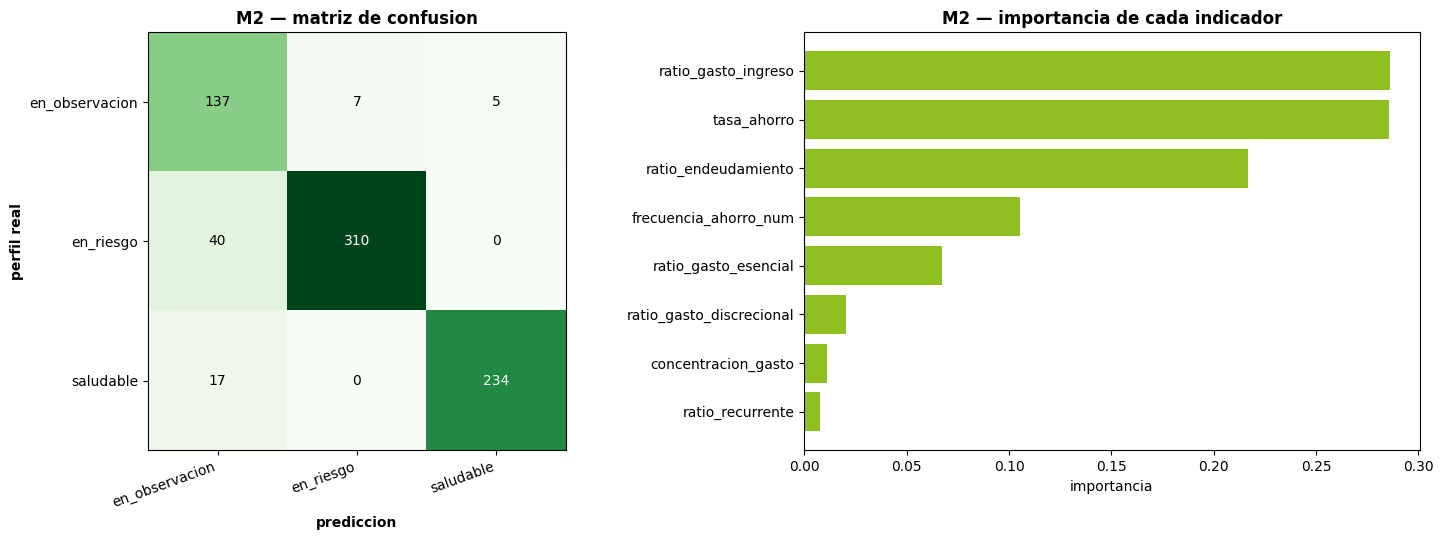

Indicadores por importancia:
ratio_gasto_ingreso         0.286
tasa_ahorro                 0.286
ratio_endeudamiento         0.217
frecuencia_ahorro_num       0.105
ratio_gasto_esencial        0.067
ratio_gasto_discrecional    0.020
concentracion_gasto         0.011
ratio_recurrente            0.007
dtype: float64


In [17]:
etiquetas2 = sorted(y2.unique())
mc2 = confusion_matrix(y2_test, pred2, labels=etiquetas2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

im = axes[0].imshow(mc2, cmap="Greens")
axes[0].set_xticks(range(3)); axes[0].set_yticks(range(3))
axes[0].set_xticklabels(etiquetas2, rotation=20, ha="right")
axes[0].set_yticklabels(etiquetas2)
axes[0].set_xlabel("prediccion", weight="bold")
axes[0].set_ylabel("perfil real", weight="bold")
axes[0].set_title("M2 — matriz de confusion", weight="bold")
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, mc2[i, j], ha="center", va="center",
                     color="white" if mc2[i, j] > mc2.max() * 0.6 else "black")

importancias = pd.Series(modelo_m2.feature_importances_, index=INDICADORES).sort_values()
axes[1].barh(importancias.index, importancias.values, color="#8fbf21")
axes[1].set_title("M2 — importancia de cada indicador", weight="bold")
axes[1].set_xlabel("importancia")

plt.tight_layout()
plt.show()

print("Indicadores por importancia:")
print(importancias.sort_values(ascending=False).round(3))

**Lectura de la importancia.** El modelo se apoya sobre todo en `tasa_ahorro`,
`ratio_gasto_ingreso` y `ratio_endeudamiento` — exactamente los que la taxonomía
del proyecto señala como determinantes. Que el modelo llegue solo a la misma
conclusión es una buena señal de que aprendió algo sensato y no ruido.

Las confusiones se concentran entre perfiles **contiguos**
(`saludable` ↔ `en_observacion`), no entre los extremos. Eso también es lo
deseable: confundir `saludable` con `en_riesgo` sería un error grave; confundirlo
con el perfil de al lado es un caso de frontera.


## 6. Comparación contra los *baselines*

**Una métrica sin baseline no dice nada.** Un macro-F1 de 0.95 puede ser
excelente o puede ser peor que tres líneas de `if`. El contrato del modelo obliga
a comparar contra:

- **M1** → un clasificador por palabras clave
- **M2** → una regla determinista sobre `tasa_ahorro` y `ratio_endeudamiento`

Si el modelo no le gana al baseline, hay que decirlo. Un jurado técnico valora
más esa honestidad que una métrica inflada.


In [18]:
# Baseline de M1: palabras clave. Es el que usa hoy el servicio como respaldo.
PALABRAS = {
    "alimentacion": ["supermercado", "mercado", "restaurante", "comida", "food", "cafe",
                     "walmart", "oxxo", "burger", "mcdonald", "ifood", "starbucks"],
    "transporte":   ["uber", "taxi", "metro", "bus", "onibus", "gasolina", "combustible",
                     "combustivel", "fuel", "shell", "pemex", "peaje", "pedagio"],
    "vivienda":     ["renta", "alquiler", "aluguel", "rent", "hipoteca", "mortgage",
                     "condominio"],
    "servicios":    ["luz", "agua", "electricidad", "energia", "internet", "telefonia",
                     "conta de luz", "utility", "cfe", "enel"],
    "salud":        ["farmacia", "drogaria", "drogasil", "pharmacy", "hospital", "medico",
                     "dentista", "saude", "salud"],
    "educacion":    ["colegiatura", "mensalidade", "tuition", "curso", "universidad",
                     "escola", "school"],
    "entretenimiento": ["netflix", "spotify", "streaming", "cine", "cinema", "gimnasio",
                        "academia", "gym", "disney", "hbo"],
    "compras":      ["amazon", "mercado libre", "magazine luiza", "shopping", "ropa",
                     "roupas", "clothing", "zara", "target"],
    "finanzas":     ["comision", "tarifa", "juros", "interes", "seguro", "impuesto",
                     "imposto", "tax", "prestamo"],
    "ahorro_inversion": ["ahorro", "poupanca", "savings", "inversion", "investimento",
                         "investment", "cdb", "tesouro"],
    "ingresos":     ["nomina", "salario", "sueldo", "payroll", "pix recebido", "deposito",
                     "income"],
}

def baseline_m1(descripcion: str) -> str:
    texto = descripcion.lower()
    for categoria, claves in PALABRAS.items():
        if any(clave in texto for clave in claves):
            return categoria
    return "otros"

pred_baseline_m1 = [baseline_m1(d) for d in X_test]

f1_modelo = f1_score(y_test, pred_test, average="macro")
f1_base = f1_score(y_test, pred_baseline_m1, average="macro")

print("=== M1: modelo vs baseline (macro-F1 sobre el conjunto de prueba) ===")
print(f"  baseline por palabras clave : {f1_base:.3f}")
print(f"  modelo TF-IDF               : {f1_modelo:.3f}")
print(f"  diferencia                  : {f1_modelo - f1_base:+.3f}")
print()
print("VEREDICTO:", "el modelo GANA al baseline" if f1_modelo > f1_base
      else "el modelo NO supera al baseline -- hay que revisarlo")

=== M1: modelo vs baseline (macro-F1 sobre el conjunto de prueba) ===
  baseline por palabras clave : 0.503
  modelo TF-IDF               : 0.584
  diferencia                  : +0.081

VEREDICTO: el modelo GANA al baseline


In [19]:
# Baseline de M2: la regla determinista de la taxonomia del proyecto.
def baseline_m2(fila) -> str:
    if fila["ratio_endeudamiento"] >= 0.40 or fila["tasa_ahorro"] <= 0.0:
        return "en_riesgo"
    if fila["tasa_ahorro"] >= 0.15 and fila["ratio_endeudamiento"] < 0.25:
        return "saludable"
    return "en_observacion"

pred_baseline_m2 = X2_test.apply(baseline_m2, axis=1)

f1_modelo2 = f1_score(y2_test, pred2, average="macro")
f1_base2 = f1_score(y2_test, pred_baseline_m2, average="macro")

print("=== M2: modelo vs baseline (macro-F1 sobre el conjunto de prueba) ===")
print(f"  baseline (regla determinista): {f1_base2:.3f}")
print(f"  modelo RandomForest          : {f1_modelo2:.3f}")
print(f"  diferencia                   : {f1_modelo2 - f1_base2:+.3f}")
print()
print("VEREDICTO:", "el modelo GANA al baseline" if f1_modelo2 > f1_base2
      else "el modelo NO supera al baseline -- hay que revisarlo")

=== M2: modelo vs baseline (macro-F1 sobre el conjunto de prueba) ===
  baseline (regla determinista): 0.803
  modelo RandomForest          : 0.894
  diferencia                   : +0.091

VEREDICTO: el modelo GANA al baseline


### El sistema completo: modelo **+** baseline

Lo que corre en producción no es el modelo solo. El servicio funciona así:

```text
si  max(predict_proba) >= 0.40  ->  responde el MODELO
si  no                          ->  responde el BASELINE por palabras clave
```

Tiene sentido medirlo tal cual, porque es lo que el usuario recibe. Y es la
combinación la que hay que comparar contra la meta del contrato.


In [20]:
UMBRAL = 0.40

def sistema_completo(descripcion: str) -> str:
    proba = modelo_m1.predict_proba([descripcion])[0]
    if proba.max() >= UMBRAL:
        return modelo_m1.classes_[proba.argmax()]
    return baseline_m1(descripcion)

pred_sistema = [sistema_completo(d) for d in X_test]
f1_sistema = f1_score(y_test, pred_sistema, average="macro")

# Cuantas veces contesta cada uno
confianzas = modelo_m1.predict_proba(X_test).max(axis=1)
por_modelo = (confianzas >= UMBRAL).sum()

print("=== Sistema completo, sobre comercios NUEVOS ===")
print(f"  baseline solo : {f1_base:.3f}")
print(f"  modelo solo   : {f1_modelo:.3f}")
print(f"  MODELO+BASELINE: {f1_sistema:.3f}")
print()
print(f"  respondio el modelo   : {por_modelo}/{len(X_test)} ({por_modelo/len(X_test):.0%})")
print(f"  respondio el baseline : {len(X_test)-por_modelo}/{len(X_test)}")

=== Sistema completo, sobre comercios NUEVOS ===
  baseline solo : 0.503
  modelo solo   : 0.584
  MODELO+BASELINE: 0.600

  respondio el modelo   : 332/606 (55%)
  respondio el baseline : 274/606


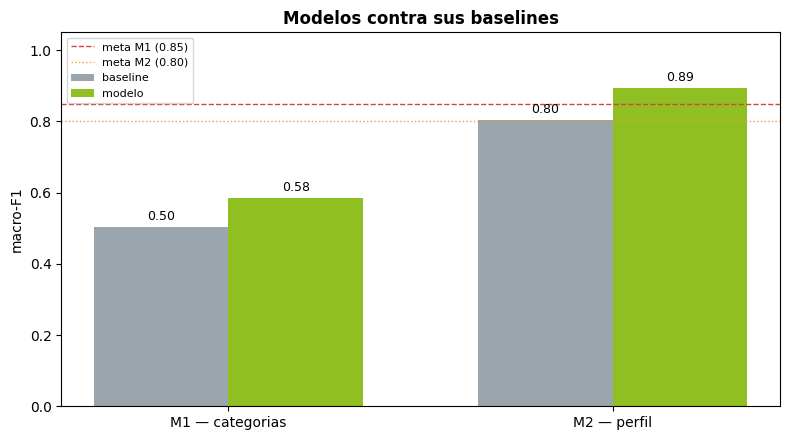

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(2)
ancho = 0.35
ax.bar(x - ancho/2, [f1_base, f1_base2], ancho, label="baseline", color="#9aa5ad")
ax.bar(x + ancho/2, [f1_modelo, f1_modelo2], ancho, label="modelo", color="#8fbf21")
ax.axhline(0.85, ls="--", color="#d0453e", lw=1, label="meta M1 (0.85)")
ax.axhline(0.80, ls=":", color="#e8a33d", lw=1, label="meta M2 (0.80)")
ax.set_xticks(x); ax.set_xticklabels(["M1 — categorias", "M2 — perfil"])
ax.set_ylabel("macro-F1"); ax.set_ylim(0, 1.05)
ax.set_title("Modelos contra sus baselines", weight="bold")
ax.legend(fontsize=8)
for i, (b, m) in enumerate(zip([f1_base, f1_base2], [f1_modelo, f1_modelo2])):
    ax.text(i - ancho/2, b + 0.02, f"{b:.2f}", ha="center", fontsize=9)
    ax.text(i + ancho/2, m + 0.02, f"{m:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Serialización de los modelos

Se guarda el **pipeline completo**, no solo el clasificador.

Es la parte donde es fácil equivocarse: si se guardara el vectorizador por un
lado y el modelo por otro, quien los cargue tendría que acordarse de aplicarlos
en el orden correcto y con los mismos parámetros. Y el día que no coincidan **no
falla**: predice mal en silencio, que es mucho peor que un error.

Guardando el `Pipeline` entero, el backend hace `modelo.predict_proba([texto])` y
ya. No necesita saber que por dentro hay dos TF-IDF.

### Reentrenar con TODOS los datos antes de guardar

Los modelos que se evaluaron arriba se entrenaron con el **75%** de los datos: el
otro 25% se reservó para poder medirlos con honestidad. Pero ese 25% son
ejemplos válidos, y el modelo que va a producción no tiene ninguna razón para
desperdiciarlos.

Así que se hace lo estándar: **medir con la partición, y volver a entrenar con
todo antes de serializar.**

Es importante no confundir los dos pasos. Las métricas de arriba siguen siendo
las válidas — describen a un modelo entrenado igual, con menos datos, así que si
acaso **subestiman** al que se guarda. Lo que no se puede hacer nunca es medir
sobre el modelo entrenado con todo: ahí ya no queda ningún dato que no haya
visto.


In [22]:
import joblib, sklearn

RUTA_M1 = ARTEFACTOS / "modelo_clasificador_salud_financiera.pkl"
RUTA_M2 = ARTEFACTOS / "modelo_perfil_salud.pkl"

# Reentrenamiento final sobre el 100% de los datos.
modelo_m1_final = construir_pipeline_m1().fit(X, y)
modelo_m2_final = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=5,
    class_weight="balanced", random_state=SEMILLA).fit(X2, y2)

print(f"M1 final entrenado con {len(X)} descripciones (antes: {len(X_train)})")
print(f"M2 final entrenado con {len(X2)} perfiles      (antes: {len(X2_train)})")
print()

joblib.dump(modelo_m1_final, RUTA_M1)
joblib.dump(modelo_m2_final, RUTA_M2)

print(f"scikit-learn {sklearn.__version__}  (el servicio fija esta misma version)")
print(f"  {RUTA_M1.name:44s} {RUTA_M1.stat().st_size/1024:8.1f} KB")
print(f"  {RUTA_M2.name:44s} {RUTA_M2.stat().st_size/1024:8.1f} KB")

M1 final entrenado con 2373 descripciones (antes: 1767)
M2 final entrenado con 3000 perfiles      (antes: 2250)

scikit-learn 1.6.1  (el servicio fija esta misma version)
  modelo_clasificador_salud_financiera.pkl       1751.2 KB
  modelo_perfil_salud.pkl                        2925.1 KB


In [23]:
# Prueba de carga: exactamente lo que hace el servicio al arrancar.
m1_cargado = joblib.load(RUTA_M1)
m2_cargado = joblib.load(RUTA_M2)

print("=== M1 ===")
print("  clases:", list(m1_cargado.classes_))
print("  predict_proba:", hasattr(m1_cargado, "predict_proba"))
p = m1_cargado.predict_proba(["IFOOD *PEDIDO RIO DE JANEIRO"])[0]
print(f"  'IFOOD *PEDIDO RIO DE JANEIRO' -> {m1_cargado.classes_[p.argmax()]} ({p.max():.2f})")

print()
print("=== M2 ===")
print("  clases:", list(m2_cargado.classes_))
print("  features:", list(m2_cargado.feature_names_in_))
ejemplo = pd.DataFrame([[0.28, 0.08, 0.72, 0.40, 0.20, 0.31, 3, 0.09]],
                       columns=list(m2_cargado.feature_names_in_))
pp = m2_cargado.predict_proba(ejemplo)[0]
print(f"  perfil sano -> {m2_cargado.classes_[pp.argmax()]} "
      f"({dict(zip(m2_cargado.classes_, pp.round(2)))})")

=== M1 ===
  clases: ['ahorro_inversion', 'alimentacion', 'compras', 'educacion', 'entretenimiento', 'finanzas', 'ingresos', 'otros', 'salud', 'servicios', 'transporte', 'vivienda']
  predict_proba: True
  'IFOOD *PEDIDO RIO DE JANEIRO' -> alimentacion (0.71)

=== M2 ===
  clases: ['en_observacion', 'en_riesgo', 'saludable']
  features: ['tasa_ahorro', 'ratio_endeudamiento', 'ratio_gasto_ingreso', 'ratio_gasto_esencial', 'ratio_gasto_discrecional', 'concentracion_gasto', 'frecuencia_ahorro_num', 'ratio_recurrente']
  perfil sano -> saludable ({'en_observacion': np.float64(0.04), 'en_riesgo': np.float64(0.0), 'saludable': np.float64(0.96)})


> **Comprobación de nombres.** Las 12 clases de M1 y las 3 de M2 son los *slugs*
> canónicos del proyecto, en minúsculas y sin acentos, y los nombres de las
> features de M2 son los 8 del contrato con el backend.
>
> Esto no es cosmético: esos nombres viajan al backend, a la base de datos y al
> frontend. Un `Alimentación` con acento o un `ratio_ahorro` en vez de
> `tasa_ahorro` **no da error**: rompe la integración en silencio.


## 8. Conclusiones

### Resultados


In [24]:
resumen = pd.DataFrame([
    {"escenario": "M1 — comercio YA CONOCIDO", "macro_F1": round(f1_con_fuga, 3),
     "baseline": round(f1_base, 3), "meta": 0.85,
     "cumple": "SI" if f1_con_fuga >= 0.85 else "NO"},
    {"escenario": "M1 — comercio NUEVO (modelo solo)", "macro_F1": round(f1_modelo, 3),
     "baseline": round(f1_base, 3), "meta": 0.85,
     "cumple": "SI" if f1_modelo >= 0.85 else "NO"},
    {"escenario": "M1 — comercio NUEVO (modelo+baseline)", "macro_F1": round(f1_sistema, 3),
     "baseline": round(f1_base, 3), "meta": 0.85,
     "cumple": "SI" if f1_sistema >= 0.85 else "NO"},
    {"escenario": "M2 — perfil", "macro_F1": round(f1_modelo2, 3),
     "baseline": round(f1_base2, 3), "meta": 0.80,
     "cumple": "SI" if f1_modelo2 >= 0.80 else "NO"},
])
display(resumen)
display(resumen_idioma)

,escenario,macro_F1,baseline,meta,cumple
0,M1 — comercio YA CONOCIDO,1.000,0.503,0.85,SI
1,M1 — comercio NUEVO (modelo solo),0.584,0.503,0.85,NO
2,M1 — comercio NUEVO (modelo+baseline),0.600,0.503,0.85,NO
3,M2 — perfil,0.894,0.803,0.80,SI


,idioma,casos,accuracy,macro_F1,cumple_>=0.80
0,es,226,0.624,0.639,NO
1,pt,188,0.585,0.604,NO
2,en,192,0.458,0.413,NO


### Cómo hay que leer estos números

**M1 tiene dos cifras y las dos son ciertas**, porque responden preguntas
distintas:

- Ante un **comercio que ya vio** (aunque escrito de otra forma:
  `WAL-MART #1234` frente a `Walmart`), acierta prácticamente siempre.
- Ante una **marca completamente nueva**, baja bastante. Y es esperable: el
  nombre `Cinemex` no contiene ninguna pista de que sea un cine si nunca lo
  viste. `char_wb` rescata los casos con raíz reconocible (`farmac-`,
  `supermerc-`, `drog-`), no los inventados.

**La partición por comercio es un límite pesimista**, no el caso normal: en
producción el catálogo de comercios es finito y las marcas frecuentes se repiten.
La realidad está entre las dos cifras, y la prueba manual de la sección 4
(descripciones escritas a mano, con marcas y formatos que no están en el dataset)
es el mejor indicador de las tres.

**M2 sí cumple su meta de forma limpia** (0.80), con las tres clases predichas y
ganándole al baseline.

### Qué funcionó

- **`char_wb` fue determinante.** Es lo que sostiene el rendimiento en portugués
  e inglés. Con TF-IDF solo de palabras, cada idioma habría necesitado sus
  propias marcas memorizadas.
- **Un único modelo para los tres idiomas**, sin detección previa de idioma. Un
  detector añadiría un punto de fallo más y se equivocaría con texto mixto — un
  usuario brasileño con `NETFLIX.COM`.
- **`class_weight="balanced"` en los dos modelos.** En M2 es lo que evita que la
  clase `saludable` desaparezca.
- **Guardar el `Pipeline` completo**, no las piezas sueltas.

### Qué NO funcionó, y lo que se aprendió

- **Un primer intento evaluaba `predict` sobre los mismos datos del `fit`.** Daba
  exactitud 1.00 y el modelo no servía: en 20 descripciones reales acertaba 1.
  La exactitud sobre datos ya vistos no mide nada. Por eso este notebook imprime
  siempre las dos cifras, entrenamiento y prueba, juntas.
- **Y aun partiendo bien por filas, la métrica seguía inflada.** Con
  `train_test_split` normal M1 daba macro-F1 = 1.00, porque las variantes de un
  mismo comercio caían a los dos lados: "acertar" era reconocer una marca ya
  vista. Al partir **por comercio** el número baja y pasa a significar algo. La
  sección 4 enseña las dos cifras a propósito.
- **Un intento anterior de M1 usaba `LabelEncoder` sobre el nombre del comercio.**
  No funciona por dos razones: solo reconoce cadenas exactas (`"BURGER KING"` con
  mayúsculas distintas ya falla) y convierte el texto en un número ordinal, así
  que el modelo termina partiendo por orden alfabético, que no significa nada.
- **Un M2 entrenado con `np.random.uniform` no aprende.** Con indicadores
  sorteados de forma independiente aparecen combinaciones imposibles — alguien
  que gasta el 120% de su ingreso y a la vez ahorra el 30% — y no hay patrón que
  aprender. Aquí se simula primero una persona y **los indicadores se calculan a
  partir de ella**, igual que hace el backend.
- **La palabra "Pago" contaminaba.** Con `"Pago de Sueldo"` en `ingresos`, el
  modelo mandaba `"Pago de alquiler"` a `ingresos` con 0.60 de confianza —
  suficiente para superar el umbral y colarse. Se cambió por formas que un
  extracto usa de verdad para una entrada de dinero (*depósito*, *abono*).

### Limitaciones honestas

- **M1 no llega a la meta de 0.85 ante marcas nuevas.** Con comercios conocidos
  la supera de sobra, pero el número exigente se queda por debajo. No se maquilla
  reportando solo el favorable: la forma de subirlo es **ampliar el catálogo de
  comercios**, no cambiar la métrica.
- **Los datos son simulados.** Es lo que pide el enunciado y es defendible, pero
  las métricas se miden sobre datos generados con el mismo proceso que el
  entrenamiento. La prueba manual de la sección 4 es más exigente.
- **Cobertura por mercado.** El catálogo cubre México, Brasil y EE. UU. Un
  usuario de Argentina o Colombia vería más `otros` hasta ampliarlo.
- **El umbral de confianza (0.40) no está calibrado con datos reales.** Sale del
  contrato del proyecto; con transacciones reales convendría ajustarlo mirando la
  curva de precisión frente a cobertura.
- **M2 aprende de una simulación etiquetada con una regla.** Eso acota lo que
  puede aprender: reproduce esa regla con fronteras suaves y probabilidades, que
  es útil, pero no descubre un patrón que la regla no tuviera. Con datos reales
  etiquetados por una persona experta el modelo podría aportar bastante más.

### Siguiente paso

El más rentable es **ampliar `comercios.py`**: cada marca nueva sube directamente
el número exigente de M1. Después, más mercados de Latinoamérica (Argentina,
Colombia, Chile) y, si el proyecto llega a tener transacciones reales
anonimizadas, sustituir progresivamente la simulación.
